## Pair trading

In [1125]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.load_data import get_data
from src.metrics import calculate_returns, display_daily_ratios, display_annualized_ratios

Select 2 tickers for the analysis

In [1126]:
ticker1 = "GOOG"
ticker2 = "GOOGL"
start_date = "2020-01-01"
end_date = "2026-12-31"

[*********************100%***********************]  1 of 1 completed


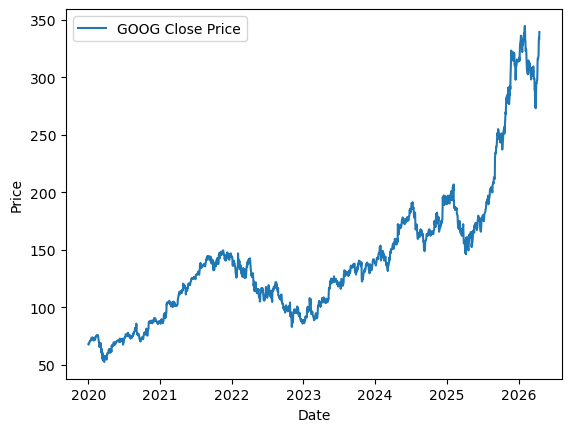

In [1127]:
data_ticker1 = get_data(ticker1, start_date, end_date)
plt.plot(data_ticker1.index, data_ticker1["Close"], label = ticker1 + " Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

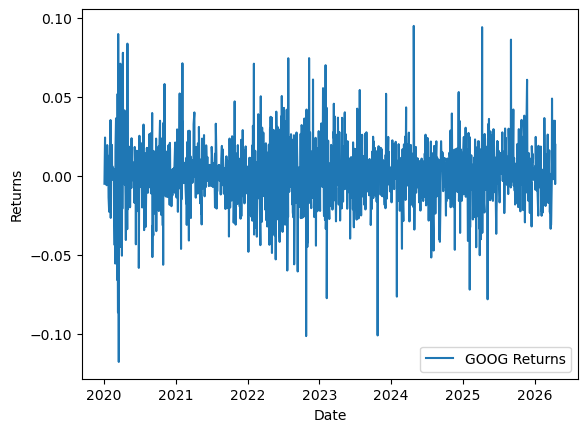

In [1128]:
data_ticker1 = calculate_returns(data_ticker1)
plt.plot(data_ticker1.index, data_ticker1["Returns"], label=ticker1 + " Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()

In [1129]:
returns_ticker1 = data_ticker1["Returns"]
display_daily_ratios(returns_ticker1)

Daily Ratios:
Volatility: 0.0202
Sharpe Ratio: 0.0505
Sortino Ratio: 0.0695


In [1130]:
display_annualized_ratios(returns_ticker1)

Annualized Ratios:
Volatility: 0.3204
Sharpe Ratio: 0.8016
Sortino Ratio: 1.1034


[*********************100%***********************]  1 of 1 completed

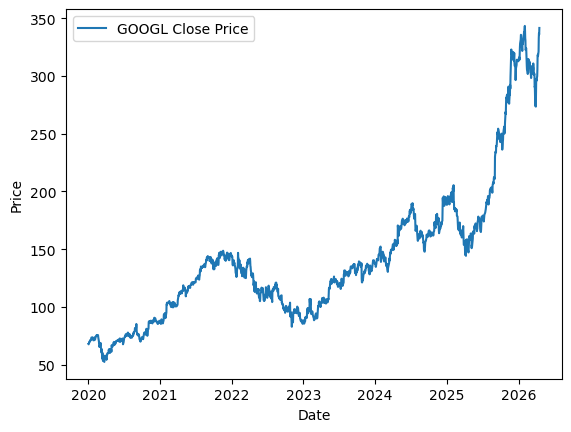

In [1131]:
data_ticker2 = get_data(ticker2, start_date, end_date)
plt.plot(data_ticker2.index, data_ticker2["Close"], label=ticker2 + " Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

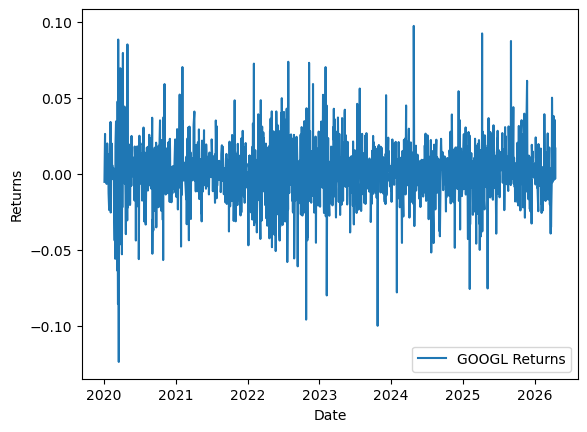

In [1132]:
data_ticker2 = calculate_returns(data_ticker2)
plt.plot(data_ticker2.index, data_ticker2["Returns"], label=ticker2 + " Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.show()

In [1133]:
returns_ticker2 = data_ticker2["Returns"]
display_daily_ratios(returns_ticker2)

Daily Ratios:
Volatility: 0.0203
Sharpe Ratio: 0.0504
Sortino Ratio: 0.0698


In [1134]:
display_annualized_ratios(returns_ticker2)

Annualized Ratios:
Volatility: 0.3223
Sharpe Ratio: 0.7997
Sortino Ratio: 1.1088


In [1135]:
norm_ticker1 = data_ticker1["Close"] / data_ticker1["Close"].iloc[0]
norm_ticker2 = data_ticker2["Close"] / data_ticker2["Close"].iloc[0]

In [1136]:
beta = returns_ticker1.cov(returns_ticker2) / returns_ticker2.var()
spread = norm_ticker1[ticker1] - beta * norm_ticker2[ticker2]

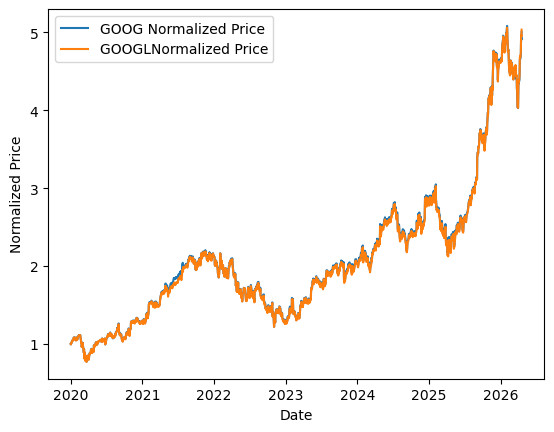

In [1137]:
plt.plot(norm_ticker1.index, norm_ticker1, label=ticker1 + " Normalized Price")
plt.plot(norm_ticker2.index, norm_ticker2, label=ticker2 + "Normalized Price")
plt.xlabel("Date") 
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

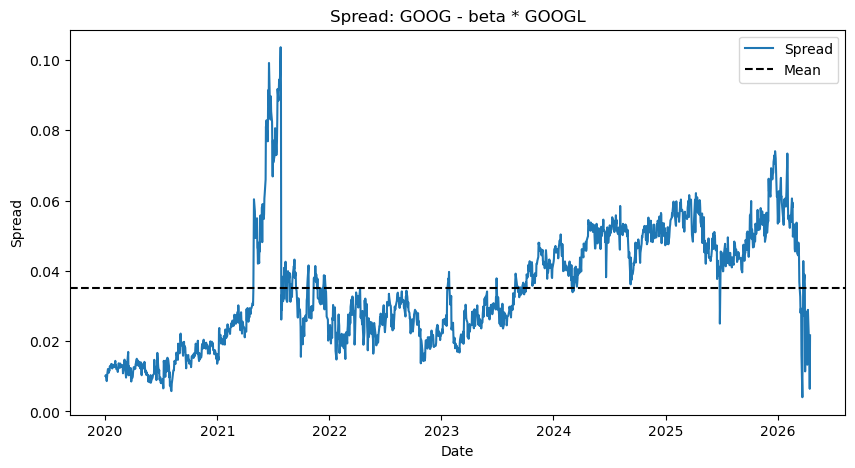

In [1138]:
plt.figure(figsize=(10, 5))
plt.plot(spread, label="Spread")
plt.axhline(spread.mean(), linestyle="--", color="black", label="Mean")
plt.title(f"Spread: {ticker1} - beta * {ticker2}")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.show()

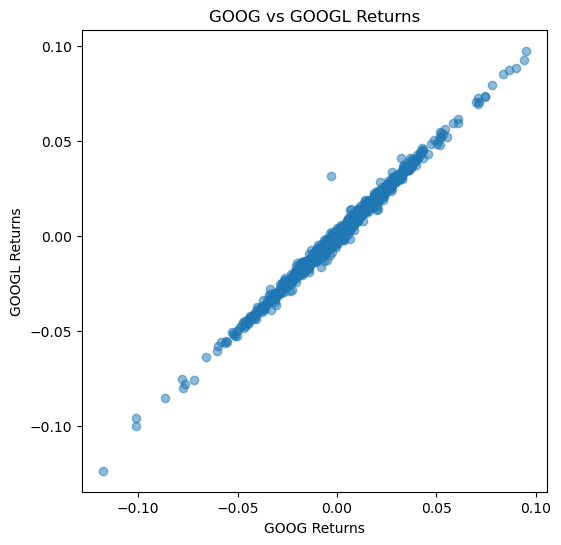

In [1139]:
plt.figure(figsize=(6, 6))
plt.scatter(returns_ticker1, returns_ticker2, alpha=0.5)
plt.title(f"{ticker1} vs {ticker2} Returns")
plt.xlabel(f"{ticker1} Returns")
plt.ylabel(f"{ticker2} Returns")
plt.show()

We take the zscore to track how many stds we are from the mean

In [1140]:
window = 30


mean = spread.rolling(window).mean().shift(1)
std = spread.rolling(window).std().shift(1)
zscore = (spread - mean) / std

zscore.tail()

Date
2026-04-13   -0.947857
2026-04-14   -1.003022
2026-04-15   -1.251482
2026-04-16   -1.878328
2026-04-17   -0.569783
dtype: float64

In [1141]:
entry_threshold_short = 2.5   # enter short spread
entry_threshold_long = -2  # enter long spread

exit_threshold_long = -0.5    # exit long spread
exit_threshold_short = 0.7    # exit short spread

signal = pd.Series(0, index=zscore.index)
position = 0

for i in range(len(zscore)):
    z = zscore.iloc[i]

    if pd.isna(z):
        signal.iloc[i] = position
        continue

    # Entry
    if position == 0:
        if z > entry_threshold_short:
            position = -1   # short spread
        elif z < entry_threshold_long:
            position = 1    # long spread

    # Exit long spread
    elif position == 1:
        if z > exit_threshold_long:
            position = 0

    # Exit short spread
    elif position == -1:
        if z < exit_threshold_short:
            position = 0

    signal.iloc[i] = position

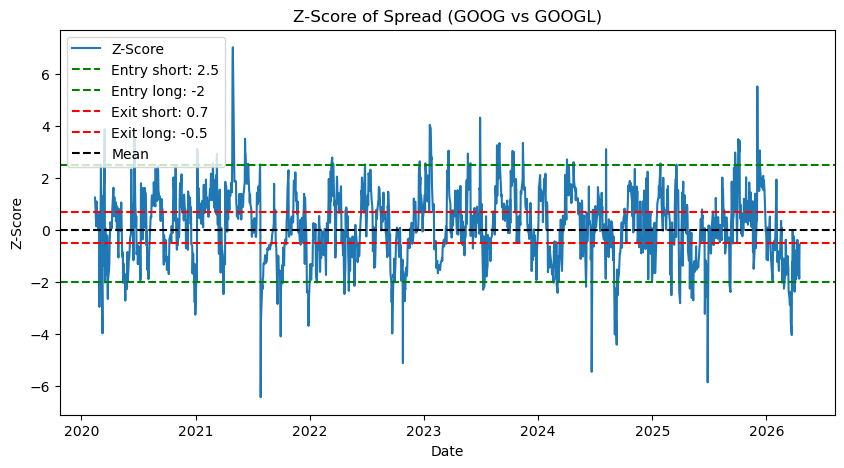

In [1142]:
plt.figure(figsize=(10, 5))
plt.plot(zscore, label="Z-Score")

# Entry thresholds
plt.axhline(entry_threshold_short, linestyle="--", color="green",
            label=f"Entry short: {entry_threshold_short}")
plt.axhline(entry_threshold_long, linestyle="--", color="green",
            label=f"Entry long: {entry_threshold_long}")

# Exit thresholds
plt.axhline(exit_threshold_short, linestyle="--", color="red",
            label=f"Exit short: {exit_threshold_short}")
plt.axhline(exit_threshold_long, linestyle="--", color="red",
            label=f"Exit long: {exit_threshold_long}")

# Mean
plt.axhline(0, linestyle="--", color="black", label="Mean")

plt.title(f"Z-Score of Spread ({ticker1} vs {ticker2})")
plt.xlabel("Date")
plt.ylabel("Z-Score")
plt.legend()
plt.show()

In [1143]:
returns_spread = returns_ticker1 - beta * returns_ticker2

signal = pd.Series(signal, index=returns_spread.index)
strategy_returns = signal.shift(1) * returns_spread

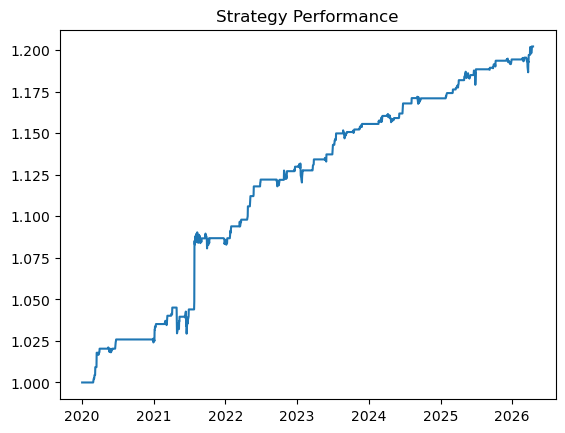

In [1144]:
cum_returns = np.exp(strategy_returns.cumsum())

plt.plot(cum_returns)
plt.title("Strategy Performance")
plt.show()

In [1145]:
display_daily_ratios(strategy_returns, risk_free_rate=0.02)

Daily Ratios:
Volatility: 0.0013
Sharpe Ratio: 0.0284
Sortino Ratio: 0.0601


In [1146]:
display_annualized_ratios(strategy_returns, risk_free_rate=0.02)

Annualized Ratios:
Volatility: 0.0207
Sharpe Ratio: 0.4515
Sortino Ratio: 0.9548


In [1147]:
print("Number of trades:", signal.diff().abs().sum())

Number of trades: 114.0


In [1148]:
positions = signal != 0
durations = positions.groupby((positions != positions.shift()).cumsum()).sum()
print("Average holding period:", durations.mean())

Average holding period: 3.382608695652174


Now we add the costs

In [1149]:
cost = 0.0005  # 5 bps
turnover = signal.diff().abs().fillna(0)

strategy_returns_net = strategy_returns - cost * turnover

display_annualized_ratios(strategy_returns_net, risk_free_rate=0.02)

Annualized Ratios:
Volatility: 0.0202
Sharpe Ratio: 0.0136
Sortino Ratio: 0.0280
